In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [28]:
# Read the CSV file using pandas and load it into a DataFrame
df = pd.read_csv("dataset/Student_performance_10k.csv")

# Display the first 5 rows of the DataFrame (to understand the structure of the data)
df.head()

,roll_no,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,science_score,total_score,grade
0,std-01,male,group D,some college,1.0,1.0,89,38.0,85.0,26.0,238.0,C
1,std-02,male,group B,high school,1.0,0.0,65,100.0,67.0,96.0,328.0,A
2,std-03,male,group C,master's degree,1.0,0.0,10,99.0,97.0,58.0,264.0,B
3,std-04,male,group D,some college,1.0,1.0,22,51.0,41.0,84.0,198.0,D
4,std-05,male,group C,some college,0.0,1.0,26,58.0,64.0,65.0,213.0,C


In [29]:
# Get the dimensions of the DataFrame (number of rows and columns)
df.shape

(10000, 12)

In [30]:
# Display a concise summary of the DataFrame (column names, data types, non-null values)
df.info()

# Generate descriptive statistics (mean, std, min, max, etc.) for numerical columns
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   roll_no                      9999 non-null   str    
 1   gender                       9982 non-null   str    
 2   race_ethnicity               9977 non-null   str    
 3   parental_level_of_education  9978 non-null   str    
 4   lunch                        9976 non-null   float64
 5   test_preparation_course      9977 non-null   float64
 6   math_score                   9976 non-null   str    
 7   reading_score                9975 non-null   float64
 8   writing_score                9976 non-null   float64
 9   science_score                9977 non-null   float64
 10  total_score                  9981 non-null   float64
 11  grade                        9997 non-null   str    
dtypes: float64(6), str(6)
memory usage: 1.3 MB


,lunch,test_preparation_course,reading_score,writing_score,science_score,total_score
count,9976.000000,9977.000000,9975.000000,9976.000000,9977.000000,9981.000000
mean,0.644246,0.388694,70.125915,71.415798,66.063045,264.740908
std,0.478765,0.487478,19.026245,18.245360,19.324331,42.304858
min,0.000000,0.000000,17.000000,10.000000,9.000000,89.000000
25%,0.000000,0.000000,57.000000,59.000000,53.000000,237.000000
50%,1.000000,0.000000,71.000000,72.500000,67.000000,268.000000
75%,1.000000,1.000000,85.000000,85.000000,81.000000,294.000000
max,1.000000,1.000000,100.000000,100.000000,100.000000,383.000000


In [31]:
# Check for missing values in each column and display their total count
df.isnull().sum()

roll_no                         1
gender                         18
race_ethnicity                 23
parental_level_of_education    22
lunch                          24
test_preparation_course        23
math_score                     24
reading_score                  25
writing_score                  24
science_score                  23
total_score                    19
grade                           3
dtype: int64

In [32]:
# Generate descriptive statistics (count, mean, standard deviation, min, max, and quartiles)
# for the numerical columns in the DataFrame
df.describe()

,lunch,test_preparation_course,reading_score,writing_score,science_score,total_score
count,9976.000000,9977.000000,9975.000000,9976.000000,9977.000000,9981.000000
mean,0.644246,0.388694,70.125915,71.415798,66.063045,264.740908
std,0.478765,0.487478,19.026245,18.245360,19.324331,42.304858
min,0.000000,0.000000,17.000000,10.000000,9.000000,89.000000
25%,0.000000,0.000000,57.000000,59.000000,53.000000,237.000000
50%,1.000000,0.000000,71.000000,72.500000,67.000000,268.000000
75%,1.000000,1.000000,85.000000,85.000000,81.000000,294.000000
max,1.000000,1.000000,100.000000,100.000000,100.000000,383.000000


In [33]:

# Loop through categorical (object-type) columns
# Fill missing values with the most frequent value (mode) of each column
for col in df.select_dtypes(include='object').columns:
    df[col].fillna(df[col].mode()[0], inplace=True)

# Loop through numerical columns (float and integer types)
# Fill missing values with the median value of each column
for col in df.select_dtypes(include=['float64', 'int64']).columns:
    df[col].fillna(df[col].median(), inplace=True)

# Verify that there are no remaining missing values in the dataset
df.isnull().sum()

C:\Users\merve\AppData\Local\Temp\ipykernel_6480\32136652.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include='object').columns:
C:\Users\merve\AppData\Local\Temp\ipykernel_6480\32136652.py:4: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[c

roll_no                         1
gender                         18
race_ethnicity                 23
parental_level_of_education    22
lunch                          24
test_preparation_course        23
math_score                     24
reading_score                  25
writing_score                  24
science_score                  23
total_score                    19
grade                           3
dtype: int64

In [34]:

# Loop through categorical (object-type) columns
# Fill missing values with the most frequent value (mode) and reassign to the column
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].fillna(df[col].mode()[0])

# Loop through numerical columns (float and integer types)
# Fill missing values with the median value and reassign to the column
for col in df.select_dtypes(include=['float64', 'int64']).columns:
    df[col] = df[col].fillna(df[col].median())

# Check if there are any remaining missing values in the dataset
df.isnull().sum()

C:\Users\merve\AppData\Local\Temp\ipykernel_6480\494197727.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include='object').columns:


roll_no                        0
gender                         0
race_ethnicity                 0
parental_level_of_education    0
lunch                          0
test_preparation_course        0
math_score                     0
reading_score                  0
writing_score                  0
science_score                  0
total_score                    0
grade                          0
dtype: int64

In [35]:
# Import LabelEncoder for converting categorical text data into numerical form
from sklearn.preprocessing import LabelEncoder

# Initialize the LabelEncoder
le = LabelEncoder()

# Loop through all categorical (object-type) columns
# Apply label encoding to transform each category into a numeric value
for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

# Display the first 5 rows to verify the transformations
df.head()

C:\Users\merve\AppData\Local\Temp\ipykernel_6480\1098857981.py:9: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include='object').columns:


,roll_no,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,science_score,total_score,grade
0,0,4,9,4,1.0,1.0,86,38.0,85.0,26.0,238.0,2
1,1,4,6,2,1.0,0.0,60,100.0,67.0,96.0,328.0,0
2,2,4,7,3,1.0,0.0,1,99.0,97.0,58.0,264.0,1
3,3,4,9,4,1.0,1.0,14,51.0,41.0,84.0,198.0,3
4,4,4,7,4,0.0,1.0,18,58.0,64.0,65.0,213.0,2


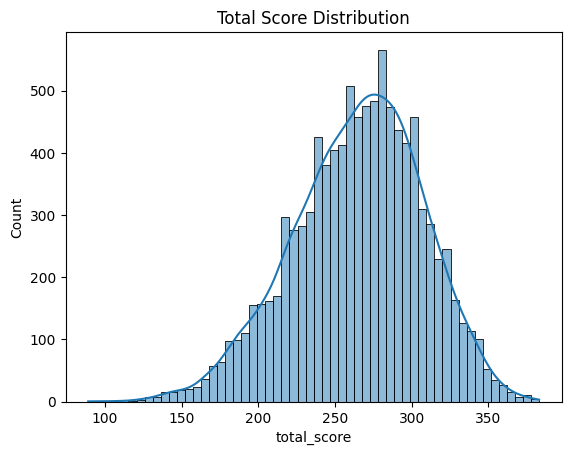

In [36]:
# Import seaborn for data visualization
import seaborn as sns

# Plot a histogram of the "total_score" column with a KDE (density curve)
sns.histplot(df["total_score"], kde=True)

# Add a title to the plot
plt.title("Total Score Distribution")

# Display the plot
plt.show()

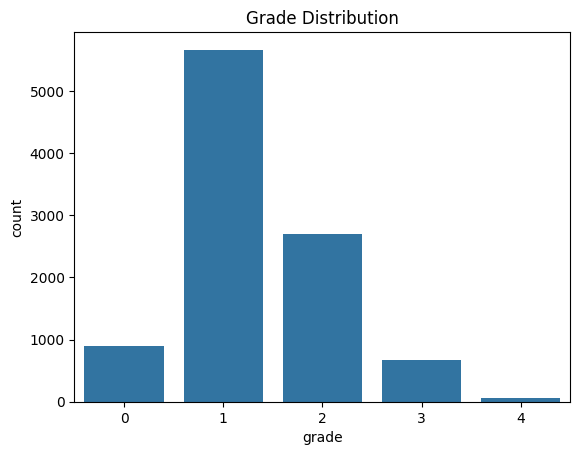

In [37]:
# Create a count plot to show the frequency of each grade category
sns.countplot(x="grade", data=df)

# Add a title to the plot
plt.title("Grade Distribution")

# Display the plot
plt.show()

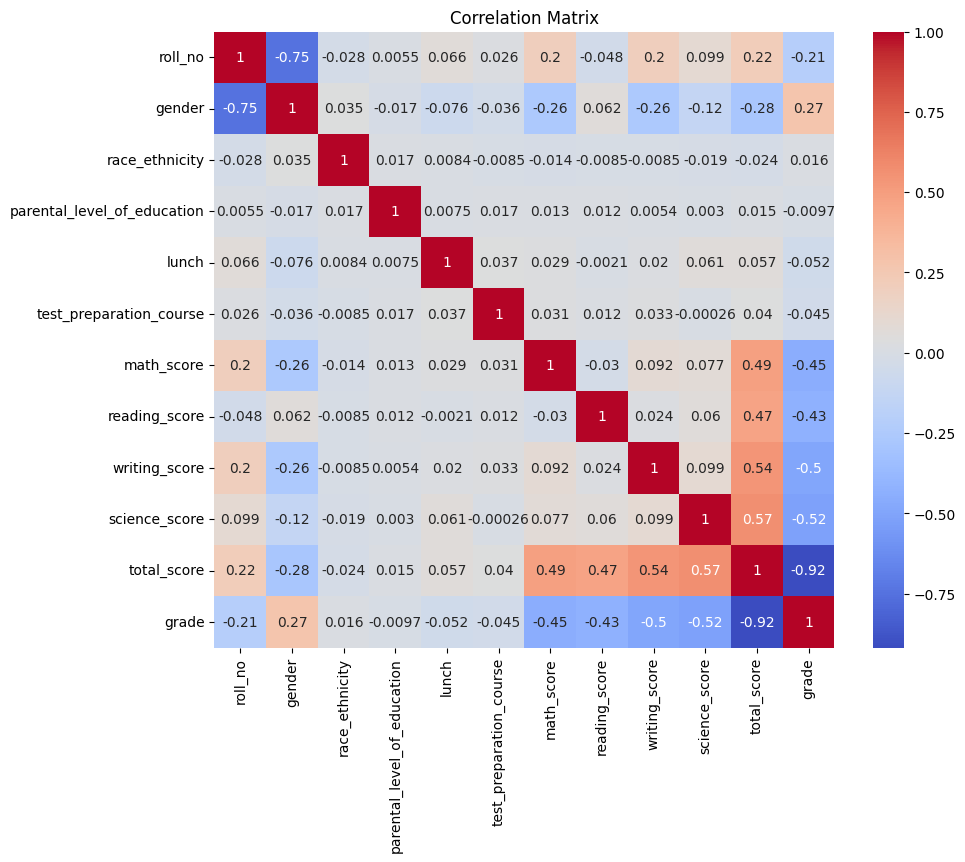

In [38]:
# Set the figure size for better readability
plt.figure(figsize=(10, 8))

# Create a heatmap to visualize the correlation matrix of the DataFrame
# annot=True shows correlation values, cmap defines the color scheme
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")

# Add a title to the plot
plt.title("Correlation Matrix")

# Display the plot
plt.show()

In [39]:
# Import required libraries for model training and evaluation
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Separate features (X) and target variable (y)
X = df.drop("grade", axis=1)  # Features (all columns except "grade")
y = df["grade"]               # Target variable

# Split the dataset into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Initialize the Random Forest classifier
model = RandomForestClassifier(random_state=42)

# Train the model using the training data
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model performance using accuracy score
accuracy_score(y_test, y_pred)

0.9985

In [40]:
# Import pandas for data handling
import pandas as pd

# Create a Series of feature importances with feature names as the index
importance = pd.Series(model.feature_importances_, index=X.columns)

# Sort feature importances in descending order to see the most important features first
importance.sort_values(ascending=False)

total_score                    0.755883
math_score                     0.061748
science_score                  0.058942
writing_score                  0.050296
reading_score                  0.046920
roll_no                        0.011529
gender                         0.005303
parental_level_of_education    0.003513
race_ethnicity                 0.003308
lunch                          0.001335
test_preparation_course        0.001223
dtype: float64

In [41]:
# Create a new feature set by removing "grade" (target) and "total_score" columns
X2 = df.drop(["grade", "total_score"], axis=1)

# Split the new dataset into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X2, y, test_size=0.2, random_state=42
)

# Initialize a new Random Forest classifier
model2 = RandomForestClassifier(random_state=42)

# Train the new model with the updated feature set
model2.fit(X_train, y_train)

# Make predictions on the test data
pred2 = model2.predict(X_test)

# Evaluate the new model using accuracy score
accuracy_score(y_test, pred2)

0.91

In [42]:
# Import different classification models and evaluation metric
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Initialize the models
dt = DecisionTreeClassifier(random_state=42)   # Decision Tree model
knn = KNeighborsClassifier()                  # K-Nearest Neighbors model
rf = RandomForestClassifier(random_state=42)  # Random Forest model

# Train each model using the training data
dt.fit(X_train, y_train)
knn.fit(X_train, y_train)
rf.fit(X_train, y_train)

# Make predictions on the test set for each model
pred_dt = dt.predict(X_test)
pred_knn = knn.predict(X_test)
pred_rf = rf.predict(X_test)

# Print accuracy scores to compare model performance
print("Decision Tree:", accuracy_score(y_test, pred_dt))
print("KNN:", accuracy_score(y_test, pred_knn))
print("Random Forest:", accuracy_score(y_test, pred_rf))

Decision Tree: 0.849
KNN: 0.7065
Random Forest: 0.91


In [43]:
# Import classification_report for detailed evaluation metrics
from sklearn.metrics import classification_report

# Print classification report for Decision Tree model
print("Decision Tree Report:")
print(classification_report(y_test, pred_dt))

# Print classification report for KNN model
print("\nKNN Report:")
print(classification_report(y_test, pred_knn))

# Print classification report for Random Forest model
print("\nRandom Forest Report:")
print(classification_report(y_test, pred_rf))

Decision Tree Report:
              precision    recall  f1-score   support

           0       0.82      0.79      0.81       187
           1       0.90      0.90      0.90      1135
           2       0.80      0.79      0.80       540
           3       0.67      0.80      0.73       124
           4       0.71      0.36      0.48        14

    accuracy                           0.85      2000
   macro avg       0.78      0.73      0.74      2000
weighted avg       0.85      0.85      0.85      2000


KNN Report:
              precision    recall  f1-score   support

           0       0.69      0.20      0.31       187
           1       0.74      0.92      0.82      1135
           2       0.63      0.59      0.61       540
           3       0.43      0.13      0.20       124
           4       0.00      0.00      0.00        14

    accuracy                           0.71      2000
   macro avg       0.50      0.37      0.39      2000
weighted avg       0.68      0.71      0.6

c:\Users\merve\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\merve\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\merve\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

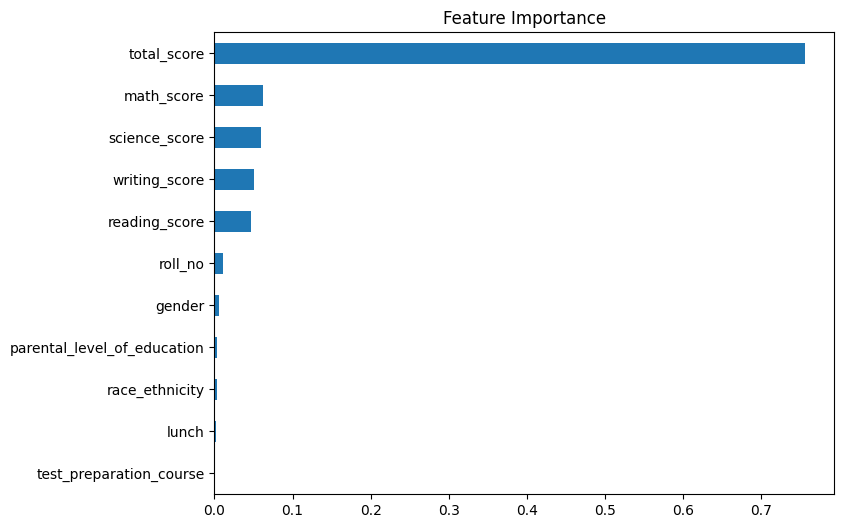

In [44]:
# Import matplotlib for visualization
import matplotlib.pyplot as plt

# Plot feature importance as a horizontal bar chart (sorted ascending for better visualization)
importance.sort_values().plot(kind='barh', figsize=(8, 6))

# Add a title to the plot
plt.title("Feature Importance")

# Display the plot
plt.show()

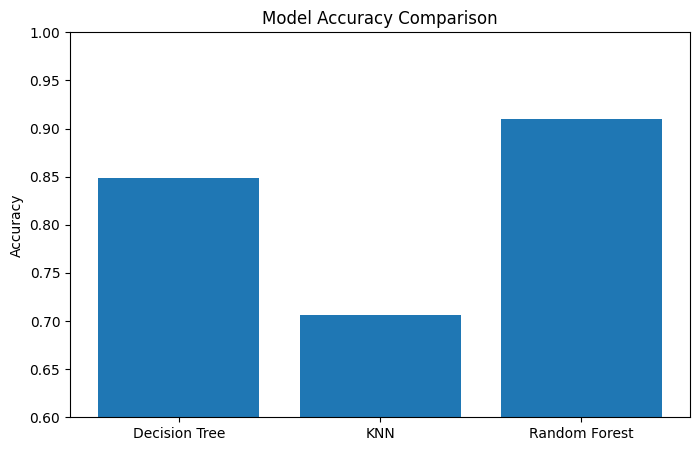

In [45]:
# Import matplotlib for visualization
import matplotlib.pyplot as plt

# Define model names and their corresponding accuracy scores
models = ["Decision Tree", "KNN", "Random Forest"]
scores = [0.849, 0.7065, 0.91]

# Create a bar chart to compare model accuracies
plt.figure(figsize=(8, 5))
plt.bar(models, scores)

# Set y-axis limits for better comparison
plt.ylim(0.6, 1.0)

# Add title and axis label
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")

# Display the plot
plt.show()

Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.72      0.83       187
           1       0.92      0.97      0.94      1135
           2       0.88      0.91      0.90       540
           3       0.87      0.73      0.79       124
           4       1.00      0.21      0.35        14

    accuracy                           0.91      2000
   macro avg       0.93      0.71      0.76      2000
weighted avg       0.91      0.91      0.91      2000



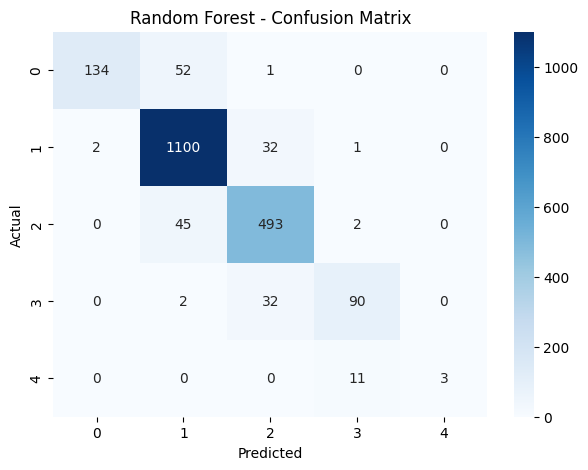

In [46]:
# Import evaluation metrics and visualization libraries
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Make predictions using the trained Random Forest model
pred_rf = rf.predict(X_test)

# Print the classification report (precision, recall, f1-score, support)
print("Classification Report:\n")
print(classification_report(y_test, pred_rf))

# Compute the confusion matrix
cm = confusion_matrix(y_test, pred_rf)

# Visualize the confusion matrix using a heatmap
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

# Add titles and labels
plt.title("Random Forest - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

# Display the plot
plt.show()